<a href="https://colab.research.google.com/github/youssef1061/XAI-project/blob/main/02_Mohamed_Dawood_Ullah2022_KNN_SMOTEENN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mohamed Dawood — Ullah et al. (2022)
## KNN

**Model ID:** `Dawood_Ullah2022_KNN`

**Paper-based justification:** Ullah et al. emphasized SMOTE-ENN balancing and reported strong KNN performance on processed BRFSS data.

**Balance:** all balancing is applied only on the training data to avoid leakage.

**XAI tools used:** Permutation Feature Importance, PDP, ICE, SHAP, LIME, and Global Surrogate.

In [2]:
MODEL_ID = "Dawood_Ullah2022_KNN"
MODEL_NAME = "Dawood_KNN_Ullah2022"


# ============================================================
# 0. Setup, Drive Mount, and Data Loading
# ============================================================
%pip -q install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap lime statsmodels joblib

import os, sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not hasattr(np, "bool"): np.bool = np.bool_
if not hasattr(np, "int"): np.int = int

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped outside Colab.", e)

from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
import shap
from lime.lime_tabular import LimeTabularExplainer
sns.set(style="whitegrid")
RANDOM_STATE = 42
TARGET = "Diabetes"

CANDIDATE_DATA_DIRS = [
    Path("/content/drive/MyDrive/BRFSS2015_processed"),
    Path("/content/artifacts"), Path("BRFSS2015_processed"), Path("artifacts"), Path(".")
]

def find_data_dir():
    for d in CANDIDATE_DATA_DIRS:
        if (d/"train.csv").exists() and (d/"test.csv").exists():
            return d
    raise FileNotFoundError("train.csv/test.csv not found. Run the EDA notebook first or place files in /content/drive/MyDrive/BRFSS2015_processed")

DATA_DIR = find_data_dir()
OUTPUT_DIR = DATA_DIR / "final_model_outputs" / MODEL_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Using DATA_DIR:", DATA_DIR)
print("Saving outputs to:", OUTPUT_DIR)

train_df = pd.read_csv(DATA_DIR/"train.csv")
test_df = pd.read_csv(DATA_DIR/"test.csv")
train_df = train_df.loc[:, ~train_df.columns.str.contains("^Unnamed")]
test_df = test_df.loc[:, ~test_df.columns.str.contains("^Unnamed")]

if TARGET not in train_df.columns:
    raise ValueError(f"Target column {TARGET} not found. Available columns: {train_df.columns.tolist()}")

for c in train_df.columns: train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
for c in test_df.columns: test_df[c] = pd.to_numeric(test_df[c], errors="coerce")
medians = train_df.median(numeric_only=True)
train_df = train_df.fillna(medians)
test_df = test_df.fillna(medians)

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET].astype(int)
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)
X_test = X_test[X_train_full.columns]
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=RANDOM_STATE)
feature_cols = list(X_train.columns)
classes = sorted(y_train_full.unique().tolist())
CLASS_NAMES = ["No Diabetes", "Prediabetes", "Diabetes"] if classes == [0,1,2] else [f"Class {c}" for c in classes]
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
display(y_train.value_counts().sort_index().to_frame("train_count"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using DATA_DIR: /content/drive/MyDrive/BRFSS2015_processed
Saving outputs to: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN
Train: (170046, 20) Validation: (30009, 20) Test: (50014, 20)


,train_count
Diabetes,
0,141578
1,4484
2,23984


In [3]:
# ============================================================
# 1. Shared Evaluation and XAI Functions
# ============================================================

def evaluate_model(y_true, y_prob):
    y_prob = np.asarray(y_prob)
    y_pred = y_prob.argmax(axis=1)
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    try:
        out["roc_auc_ovr_macro"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
        out["roc_auc_ovr_weighted"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
    except Exception as e:
        out["roc_auc_ovr_macro"] = np.nan
        out["roc_auc_ovr_weighted"] = np.nan
        print("ROC-AUC warning:", e)
    return out

def metrics_frame(model_name, split_name, y_true, y_prob):
    row = {"model": model_name, "split": split_name}
    row.update(evaluate_model(y_true, y_prob))
    return pd.DataFrame([row])

def report_and_confusion(model_name, y_true, y_prob):
    y_pred = np.asarray(y_prob).argmax(axis=1)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", xticks_rotation=20)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    path = OUTPUT_DIR/f"{model_name}_confusion_matrix.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)
    plt.show()

def plot_multiclass_roc_pr(model, model_name):
    y_prob = model.predict_proba(X_test)
    plt.figure(figsize=(8,6))
    for idx, cls in enumerate(classes):
        y_bin = (y_test == cls).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_prob[:, idx])
        plt.plot(fpr, tpr, label=f"{CLASS_NAMES[idx]} AUC={auc(fpr,tpr):.3f}")
    plt.plot([0,1],[0,1],"--", color="gray")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curves")
    plt.legend(); plt.tight_layout()
    path = OUTPUT_DIR/f"{model_name}_roc_curves.png"
    plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()

    plt.figure(figsize=(8,6))
    for idx, cls in enumerate(classes):
        y_bin = (y_test == cls).astype(int)
        p, r, _ = precision_recall_curve(y_bin, y_prob[:, idx])
        ap = average_precision_score(y_bin, y_prob[:, idx])
        plt.plot(r, p, label=f"{CLASS_NAMES[idx]} AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curves")
    plt.legend(); plt.tight_layout()
    path = OUTPUT_DIR/f"{model_name}_pr_curves.png"
    plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()

def get_class_index(model, target_label=2):
    model_classes = getattr(model, "classes_", None)
    if model_classes is None and hasattr(model, "named_steps"):
        model_classes = getattr(list(model.named_steps.values())[-1], "classes_", classes)
    if model_classes is None: model_classes = classes
    model_classes = list(model_classes)
    return model_classes.index(target_label) if target_label in model_classes else len(model_classes)-1

def predict_proba_df(model, data):
    if not isinstance(data, pd.DataFrame): data = pd.DataFrame(data, columns=feature_cols)
    return model.predict_proba(data)

def save_model_metrics(model, model_name):
    val_prob = model.predict_proba(X_val)
    test_prob = model.predict_proba(X_test)
    metrics = pd.concat([metrics_frame(model_name,"validation",y_val,val_prob), metrics_frame(model_name,"test",y_test,test_prob)], ignore_index=True)
    display(metrics)
    metrics.to_csv(OUTPUT_DIR/f"{model_name}_metrics.csv", index=False)
    report_and_confusion(model_name, y_test, test_prob)
    plot_multiclass_roc_pr(model, model_name)
    return metrics

def run_permutation_importance_xai(model, model_name):
    print("XAI 1: Permutation Feature Importance")
    pfi = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring="roc_auc_ovr_weighted", n_jobs=-1)
    df = pd.DataFrame({"feature": feature_cols, "importance_mean": pfi.importances_mean, "importance_std": pfi.importances_std}).sort_values("importance_mean", ascending=False)
    display(df.head(15)); df.to_csv(OUTPUT_DIR/f"{model_name}_pfi.csv", index=False)
    plt.figure(figsize=(8,6)); sns.barplot(data=df.head(12), x="importance_mean", y="feature", orient="h")
    plt.title(f"{model_name} - Permutation Feature Importance"); plt.tight_layout()
    path = OUTPUT_DIR/f"{model_name}_pfi.png"; plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()
    return df

def run_pdp_ice_xai(model, model_name, target_label=2):
    print("XAI 2 and 3: PDP + ICE")
    selected = [f for f in ["BMI","Age","GenHlth","HighBP"] if f in X_test.columns] or feature_cols[:4]
    X_small = X_test.sample(min(1500, len(X_test)), random_state=RANDOM_STATE)
    try:
        PartialDependenceDisplay.from_estimator(model, X_small, selected, target=target_label, kind="average", grid_resolution=20)
        plt.suptitle(f"{model_name} - PDP for class {target_label}", y=1.02); plt.tight_layout()
        path = OUTPUT_DIR/f"{model_name}_pdp.png"; plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()
    except Exception as e: print("PDP failed:", e)
    try:
        PartialDependenceDisplay.from_estimator(model, X_small, selected[:2], target=target_label, kind="individual", subsample=60, grid_resolution=15, random_state=RANDOM_STATE)
        plt.suptitle(f"{model_name} - ICE for class {target_label}", y=1.02); plt.tight_layout()
        path = OUTPUT_DIR/f"{model_name}_ice.png"; plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()
    except Exception as e: print("ICE failed:", e)

def run_shap_xai(model, model_name, target_label=2, background_size=50, explain_size=50):
    print("XAI 4: SHAP")
    class_idx = get_class_index(model, target_label)
    background = shap.sample(X_train, min(background_size, len(X_train)), random_state=RANDOM_STATE)
    explain_X = shap.sample(X_test, min(explain_size, len(X_test)), random_state=RANDOM_STATE)
    def f(data): return predict_proba_df(model, data)[:, class_idx]
    try:
        explainer = shap.KernelExplainer(f, background)
        vals = explainer.shap_values(explain_X, nsamples=100)
        shap.summary_plot(vals, explain_X, feature_names=feature_cols, show=False)
        plt.title(f"{model_name} - SHAP Summary for class {target_label}")
        path = OUTPUT_DIR/f"{model_name}_shap_summary.png"; plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()
        np.save(OUTPUT_DIR/f"{model_name}_shap_values.npy", np.asarray(vals))
        return vals, explain_X
    except Exception as e:
        print("SHAP failed but notebook continues:", e)
        (OUTPUT_DIR/f"{model_name}_shap_error.txt").write_text(str(e))
        return None, explain_X

def run_lime_xai(model, model_name, instance_index=0, num_features=10):
    print("XAI 5: LIME")
    try:
        explainer = LimeTabularExplainer(X_train.values, feature_names=feature_cols, class_names=CLASS_NAMES, discretize_continuous=True, mode="classification", random_state=RANDOM_STATE)
        exp = explainer.explain_instance(X_test.iloc[instance_index].values, lambda x: predict_proba_df(model, x), num_features=num_features, top_labels=len(CLASS_NAMES))
        print("True label:", y_test.iloc[instance_index])
        print("Predicted probabilities:", model.predict_proba(X_test.iloc[[instance_index]])[0])
        path = OUTPUT_DIR/f"{model_name}_lime_instance_{instance_index}.html"
        exp.save_to_file(str(path)); print("Saved:", path)
        exp.show_in_notebook(show_table=True)
        return exp
    except Exception as e:
        print("LIME failed but notebook continues:", e)
        (OUTPUT_DIR/f"{model_name}_lime_error.txt").write_text(str(e))
        return None

def run_global_surrogate_xai(model, model_name, max_depth=3):
    print("XAI 6: Global surrogate decision tree")
    X_sur = X_train.sample(min(6000, len(X_train)), random_state=RANDOM_STATE)
    y_black = model.predict(X_sur)
    surrogate = DecisionTreeClassifier(max_depth=max_depth, random_state=RANDOM_STATE)
    surrogate.fit(X_sur, y_black)
    fidelity = accuracy_score(model.predict(X_test), surrogate.predict(X_test))
    print("Surrogate fidelity:", fidelity)
    plt.figure(figsize=(18,8))
    plot_tree(surrogate, feature_names=feature_cols, class_names=CLASS_NAMES, filled=True, rounded=True, fontsize=8)
    plt.title(f"{model_name} - Global Surrogate Tree, fidelity={fidelity:.3f}")
    path = OUTPUT_DIR/f"{model_name}_global_surrogate.png"; plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()
    pd.DataFrame([{"model": model_name, "surrogate_fidelity": fidelity}]).to_csv(OUTPUT_DIR/f"{model_name}_surrogate_fidelity.csv", index=False)
    return surrogate, fidelity

def run_learning_curve_plot(model, model_name):
    print("Diagnostic: Learning Curve")
    try:
        train_sizes, train_scores, val_scores = learning_curve(model, X_train, y_train, cv=3, scoring="f1_weighted", train_sizes=np.linspace(0.2,1.0,4), n_jobs=-1)
        plt.figure(figsize=(8,5))
        plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training F1-weighted")
        plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV F1-weighted")
        plt.xlabel("Training size"); plt.ylabel("F1-weighted"); plt.title(f"{model_name} - Learning Curve"); plt.legend(); plt.tight_layout()
        path = OUTPUT_DIR/f"{model_name}_learning_curve.png"; plt.savefig(path, dpi=200, bbox_inches="tight"); print("Saved:", path); plt.show()
    except Exception as e: print("Learning curve skipped:", e)

def run_full_xai_suite(model, model_name, target_label=2):
    pfi = run_permutation_importance_xai(model, model_name)
    run_pdp_ice_xai(model, model_name, target_label)
    shap_values, shap_X = run_shap_xai(model, model_name, target_label)
    lime_exp = run_lime_xai(model, model_name)
    surrogate, fidelity = run_global_surrogate_xai(model, model_name)
    return {"pfi": pfi, "shap": shap_values, "lime": lime_exp, "surrogate": surrogate, "fidelity": fidelity}

## 2. Model construction and training

In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier

model = ImbPipeline([("scale", QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE)), ("balance", SMOTEENN(random_state=RANDOM_STATE)), ("model", KNeighborsClassifier(n_neighbors=7, weights="distance"))])
model.fit(X_train, y_train)
print("Model trained:", MODEL_NAME)

Model trained: Dawood_KNN_Ullah2022


## 3. Evaluation

,model,split,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro,roc_auc_ovr_weighted
0,Dawood_KNN_Ullah2022,validation,0.568729,0.410230,0.462133,0.379897,0.811087,0.568729,0.643292,0.651787,0.709786
1,Dawood_KNN_Ullah2022,test,0.566721,0.411625,0.472353,0.381513,0.811637,0.566721,0.641088,0.657452,0.710523


              precision    recall  f1-score   support

 No Diabetes     0.9276    0.5668    0.7037     41641
 Prediabetes     0.0352    0.2191    0.0607      1319
    Diabetes     0.2720    0.6311    0.3802      7054

    accuracy                         0.5667     50014
   macro avg     0.4116    0.4724    0.3815     50014
weighted avg     0.8116    0.5667    0.6411     50014

Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_confusion_matrix.png


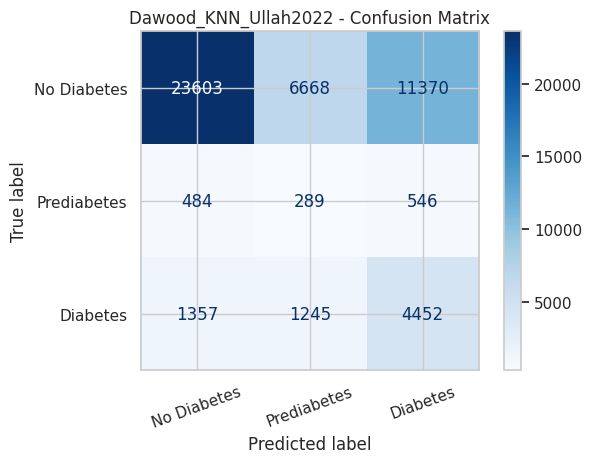

Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_roc_curves.png


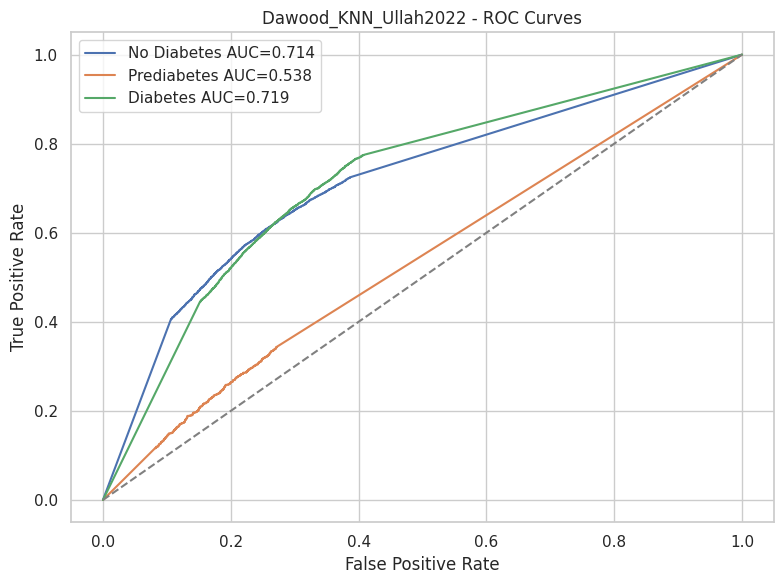

Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_pr_curves.png


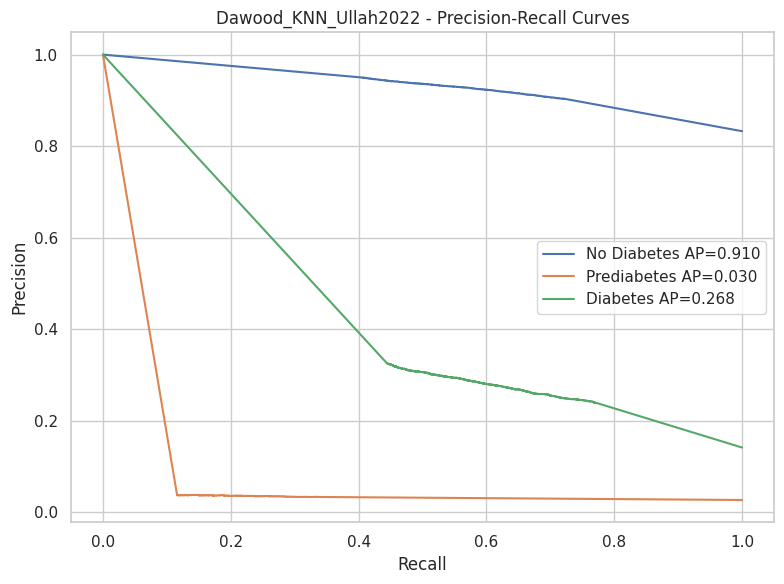

In [5]:
metrics = save_model_metrics(model, MODEL_NAME)

## 4. Learning diagnostics

In [ ]:
run_learning_curve_plot(model, MODEL_NAME)

Diagnostic: Learning Curve


## 5. Explainability suite

XAI 1: Permutation Feature Importance


,feature,importance_mean,importance_std
0,GenHlth,0.030183,0.000809
1,HighBP,0.029563,0.002308
5,HighChol,0.009494,0.000588
15,BMI,0.006526,0.001705
8,BMI_class,0.006175,0.001174
19,Age,0.005955,0.000485
3,BMI_x_Age,0.005571,0.001311
7,Sex,0.005147,0.000944
18,TimeSinceCheckup,0.004571,0.000855
4,CV_burden_weighted,0.004223,0.000588


Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_pfi.png


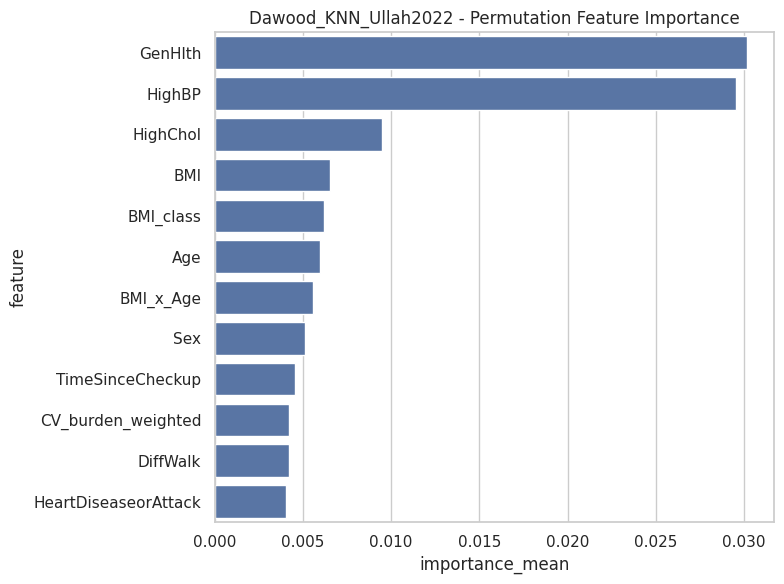

XAI 2 and 3: PDP + ICE
Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_pdp.png


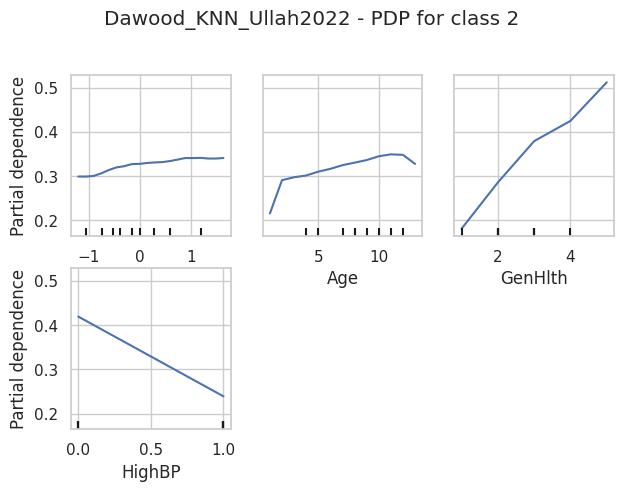

Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_ice.png


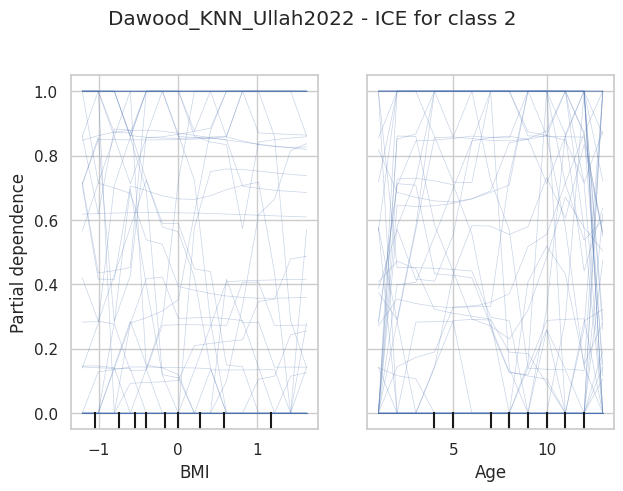

XAI 4: SHAP


  0%|          | 0/50 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_shap_summary.png


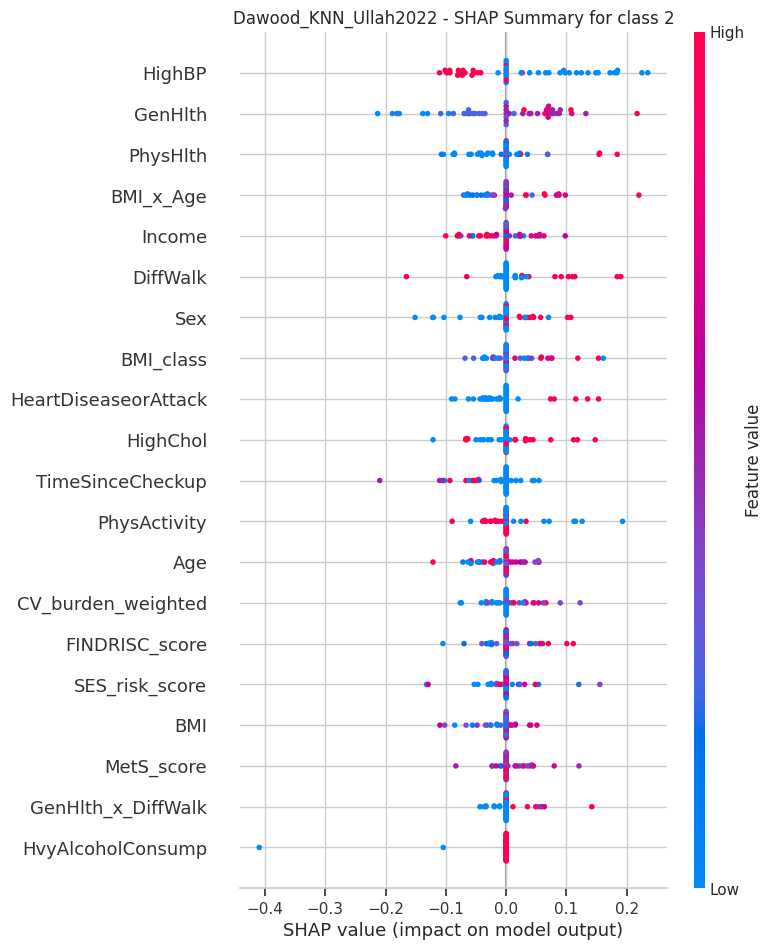

XAI 5: LIME
True label: 0
Predicted probabilities: [1. 0. 0.]
Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_lime_instance_0.html


XAI 6: Global surrogate decision tree
Surrogate fidelity: 0.6588755148558404
Saved: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs/Dawood_Ullah2022_KNN/Dawood_KNN_Ullah2022_global_surrogate.png


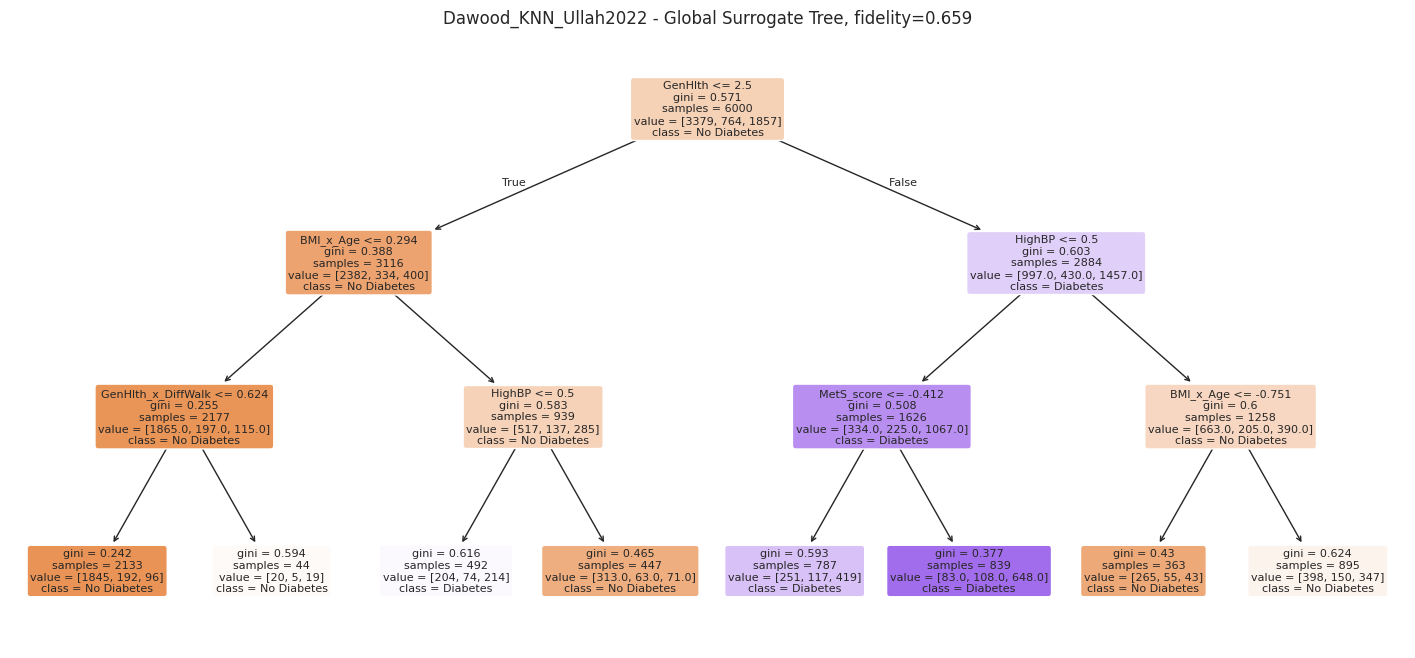

In [11]:
xai_outputs = run_full_xai_suite(model, MODEL_NAME, target_label=2)